# Further Integrals: Exponential and Trigonometric Functions

A guided notebook on more functions with **immediate antiderivatives**:

- integrals of exponential functions $a^{kx}$
- integrals of $\sin(x)$ and $\cos(x)$
- integrals of $\sec^2(x)$ and $\csc^2(x)$

These are sometimes called **immediate** or **elementary** integrals because they follow directly from derivatives you already know.

This notebook follows the same style template as the uploaded guidelines.

## 1. Introduction

Polynomial functions belong to a group of integrands with **common antiderivatives**. Their indefinite integrals are called *immediate* or *elementary* integrals because they immediately follow from the derivatives we already know.

In this notebook we extend the catalogue of immediate integrals beyond constants and powers to include:

- **exponential functions**,
- the **sine** and **cosine** functions,
- the **secant-squared** and **cosecant-squared** functions.

The guiding idea throughout: *every integration rule is a differentiation rule read backwards.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## 2. Integral of Exponential Functions

An exponential function has the form

$$
f(x) = a^{kx}.
$$

To integrate it, recall its derivative:

$$
\frac{d}{dx}\,a^{kx} = k\cdot a^{kx}\cdot \ln(a).
$$

Rearranging the factors,

$$
a^{kx} = \frac{1}{k\cdot \ln(a)}\cdot \frac{d}{dx}\left(a^{kx}\right).
$$

Integrating both sides gives the rule:

$$
\boxed{\;\int a^{kx}\,dx = \frac{a^{kx}}{k\cdot \ln(a)} + C\;}
$$

### The natural exponential function

Consider the special case $a = e \approx 2.71828$ and $k = 1$. The function becomes the **natural exponential function**:

$$
f(x) = e^x.
$$

Because $\ln(e) = 1$ and $k = 1$, the rule simplifies to

$$
\int e^x\,dx = \frac{e^x}{1\cdot \ln(e)} + C = e^x + C.
$$

This is a direct reminder that the derivative of the natural exponential function is still the natural exponential function!

In [2]:
x = sp.symbols('x', real=True)
a, k = sp.symbols('a k', positive=True)

print("General rule:")
print("  integral of a^(kx) =", sp.integrate(a**(k*x), x))
print()
print("Special cases:")
print("  integral of e^x   =", sp.integrate(sp.exp(x), x), "+ C")
print("  integral of 2^x   =", sp.integrate(2**x, x), "+ C")
print("  integral of e^(3x) =", sp.integrate(sp.exp(3*x), x), "+ C")

General rule:
  integral of a^(kx) = Piecewise((a**(k*x)/(k*log(a)), Ne(k*log(a), 0)), (x, True))

Special cases:
  integral of e^x   = exp(x) + C
  integral of 2^x   = 2**x/log(2) + C
  integral of e^(3x) = exp(3*x)/3 + C


### Worked example

Compute $\displaystyle\int 2^{3x}\,dx$.

Here $a = 2$ and $k = 3$, so

$$
\int 2^{3x}\,dx = \frac{2^{3x}}{3\,\ln(2)} + C.
$$

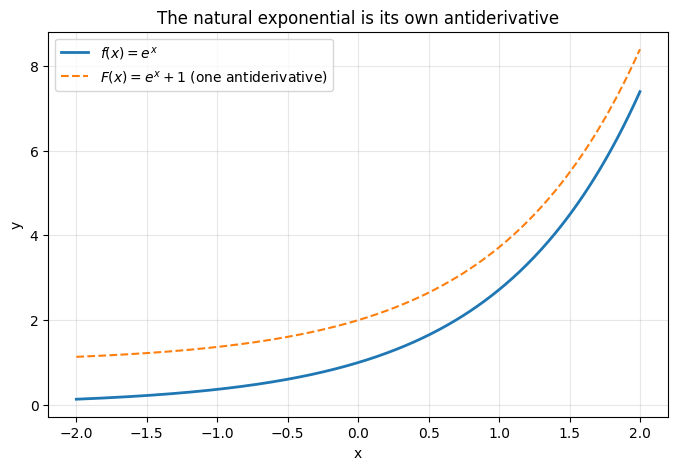

In [3]:
xv = np.linspace(-2, 2, 400)
f_vals = np.exp(xv)        # f(x) = e^x
F_vals = np.exp(xv)        # F(x) = e^x  (an antiderivative, with C = 0)

plt.figure(figsize=(8, 5))
plt.plot(xv, f_vals, label=r"$f(x) = e^x$", linewidth=2)
plt.plot(xv, F_vals + 1, '--', label=r"$F(x) = e^x + 1$ (one antiderivative)")
plt.title("The natural exponential is its own antiderivative")
plt.xlabel("x"); plt.ylabel("y")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 3. Integral of Sine and Cosine

Sine and cosine share a neat **cyclical** relationship under differentiation:

$$
\begin{aligned}
\frac{d}{dx}\sin(x) &= \cos(x) \\
\frac{d}{dx}\cos(x) &= -\sin(x) \\
\frac{d}{dx}\big[-\sin(x)\big] &= -\cos(x) \\
\frac{d}{dx}\big[-\cos(x)\big] &= \sin(x)
\end{aligned}
$$

Since each function is the antiderivative of the one above it, the cyclical pattern carries over to integration. Reading those derivatives backwards:

$$
\begin{aligned}
\int \sin(x)\,dx &= -\cos(x) + C \\
\int \cos(x)\,dx &= \sin(x) + C \\
\int -\sin(x)\,dx &= \cos(x) + C \\
\int -\cos(x)\,dx &= -\sin(x) + C
\end{aligned}
$$

The two essential rules to remember are:

$$
\boxed{\;\int \sin(x)\,dx = -\cos(x) + C\;}
\qquad
\boxed{\;\int \cos(x)\,dx = \sin(x) + C\;}
$$

In [4]:
print("integral of sin(x)  =", sp.integrate(sp.sin(x), x), "+ C")
print("integral of cos(x)  =", sp.integrate(sp.cos(x), x), "+ C")
print("integral of -sin(x) =", sp.integrate(-sp.sin(x), x), "+ C")
print("integral of -cos(x) =", sp.integrate(-sp.cos(x), x), "+ C")

integral of sin(x)  = -cos(x) + C
integral of cos(x)  = sin(x) + C
integral of -sin(x) = cos(x) + C
integral of -cos(x) = -sin(x) + C


### A geometric view: the $\pi/2$ shift

Another way to see the cyclical relationship is through the graphs. **Differentiation shifts the argument by $\pi/2$ in one direction**, while **integration shifts it in the opposite direction**.

For example, $\cos(x) = \sin\!\left(x + \tfrac{\pi}{2}\right)$, which is exactly $\sin(x)$ shifted left — and indeed $\frac{d}{dx}\sin(x) = \cos(x)$.

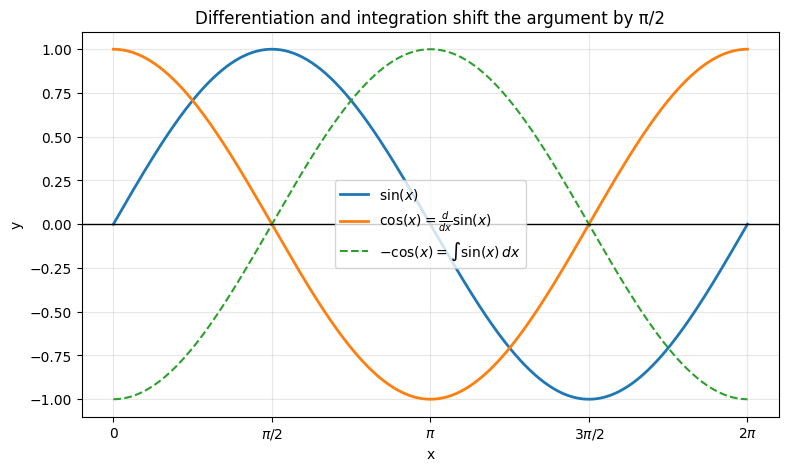

In [5]:
xv = np.linspace(0, 2*np.pi, 400)

plt.figure(figsize=(9, 5))
plt.plot(xv, np.sin(xv), label=r"$\sin(x)$", linewidth=2)
plt.plot(xv, np.cos(xv), label=r"$\cos(x) = \frac{d}{dx}\sin(x)$", linewidth=2)
plt.plot(xv, -np.cos(xv), '--', label=r"$-\cos(x) = \int \sin(x)\,dx$")
plt.title("Differentiation and integration shift the argument by \u03c0/2")
plt.xlabel("x"); plt.ylabel("y")
plt.axhline(0, lw=1, color='black')
plt.xticks(np.linspace(0, 2*np.pi, 5),
           ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 4. Integral of $\sec^2(x)$ and $\csc^2(x)$

The integrals

$$
\int \sec^2(x)\,dx \qquad\text{and}\qquad \int \csc^2(x)\,dx
$$

look intricate, but they too have immediate antiderivatives. We just need the derivatives of $\tan$ and $\cot$.

**Derivative of the tangent** (quotient rule on $\sin/\cos$):

$$
\frac{d}{dx}\tan(x) = \frac{d}{dx}\!\left(\frac{\sin(x)}{\cos(x)}\right)
= \cos(x)\cdot\frac{1}{\cos(x)} + \sin(x)\cdot\frac{\sin(x)}{\cos^2(x)}
= 1 + \tan^2(x).
$$

**Derivative of the cotangent:**

$$
\frac{d}{dx}\cot(x) = \frac{d}{dx}\!\left(\frac{\cos(x)}{\sin(x)}\right)
= -\sin(x)\cdot\frac{1}{\sin(x)} - \cos(x)\cdot\frac{\cos(x)}{\sin^2(x)}
= -1 - \cot^2(x).
$$

### Connecting to the Pythagorean identity

Start from the fundamental trigonometric identity:

$$
\sin^2(x) + \cos^2(x) = 1.
$$

Dividing both sides by $\cos^2(x)$:

$$
\frac{\sin^2(x)}{\cos^2(x)} + \frac{\cos^2(x)}{\cos^2(x)} = \frac{1}{\cos^2(x)}
\;\Longrightarrow\;
\tan^2(x) + 1 = \sec^2(x).
$$

Dividing instead by $\sin^2(x)$:

$$
\frac{\sin^2(x)}{\sin^2(x)} + \frac{\cos^2(x)}{\sin^2(x)} = \frac{1}{\sin^2(x)}
\;\Longrightarrow\;
1 + \cot^2(x) = \csc^2(x).
$$

Substituting these into the derivatives above:

$$
\frac{d}{dx}\tan(x) = \sec^2(x)
\;\Longrightarrow\;
\boxed{\;\int \sec^2(x)\,dx = \tan(x) + C\;}
$$

$$
\frac{d}{dx}\cot(x) = -\csc^2(x)
\;\Longrightarrow\;
\boxed{\;\int \csc^2(x)\,dx = -\cot(x) + C\;}
$$

In [6]:
# Verify the identities and the integrals symbolically
print("d/dx tan(x) =", sp.simplify(sp.diff(sp.tan(x), x)),
      "  (equals sec^2:", sp.simplify(sp.diff(sp.tan(x), x) - sp.sec(x)**2) == 0, ")")
print("d/dx cot(x) =", sp.simplify(sp.diff(sp.cot(x), x)),
      "  (equals -csc^2:", sp.simplify(sp.diff(sp.cot(x), x) + sp.csc(x)**2) == 0, ")")
print()
print("integral of sec^2(x) =", sp.integrate(sp.sec(x)**2, x), "+ C")
print("integral of csc^2(x) =", sp.integrate(sp.csc(x)**2, x), "+ C")

d/dx tan(x) = cos(x)**(-2)   (equals sec^2: True )
d/dx cot(x) = -1/sin(x)**2   (equals -csc^2: True )

integral of sec^2(x) = sin(x)/cos(x) + C
integral of csc^2(x) = -cos(x)/sin(x) + C


## 5. Summary Table of New Rules

| Integrand $f(x)$ | Antiderivative $\int f(x)\,dx$ |
|------------------|--------------------------------|
| $a^{kx}$         | $\dfrac{a^{kx}}{k\,\ln(a)} + C$ |
| $e^x$            | $e^x + C$ |
| $\sin(x)$        | $-\cos(x) + C$ |
| $\cos(x)$        | $\sin(x) + C$ |
| $\sec^2(x)$      | $\tan(x) + C$ |
| $\csc^2(x)$      | $-\cot(x) + C$ |

## 6. A Definite Integral Example

Using the new rules, compute

$$
\int_0^{\pi} \sin(x)\,dx.
$$

An antiderivative is $F(x) = -\cos(x)$, so

$$
\int_0^{\pi} \sin(x)\,dx = \big[-\cos(x)\big]_0^{\pi}
= -\cos(\pi) - \big(-\cos(0)\big) = -(-1) + 1 = 2.
$$

This value is the area under one arch of the sine curve.

definite integral of sin(x) from 0 to pi = 2


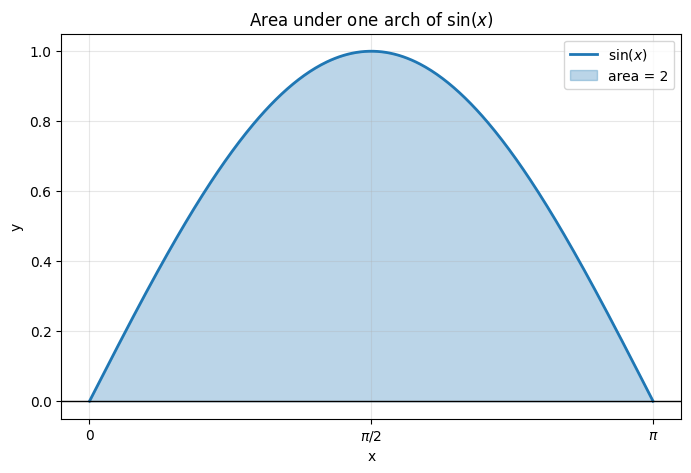

In [7]:
result = sp.integrate(sp.sin(x), (x, 0, sp.pi))
print("definite integral of sin(x) from 0 to pi =", result)

xv = np.linspace(0, np.pi, 400)
plt.figure(figsize=(8, 5))
plt.plot(xv, np.sin(xv), color='tab:blue', linewidth=2, label=r"$\sin(x)$")
plt.fill_between(xv, np.sin(xv), alpha=0.3, color='tab:blue', label="area = 2")
plt.title(r"Area under one arch of $\sin(x)$")
plt.xlabel("x"); plt.ylabel("y")
plt.axhline(0, lw=1, color='black')
plt.xticks([0, np.pi/2, np.pi], ['0', r'$\pi/2$', r'$\pi$'])
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 7. Exercises

### Basic

1. Compute $\displaystyle\int e^x\,dx$.
2. Compute $\displaystyle\int \cos(x)\,dx$.
3. Compute $\displaystyle\int \sec^2(x)\,dx$.

### Intermediate

4. Compute $\displaystyle\int 3^{2x}\,dx$.
5. Compute $\displaystyle\int \big(\sin(x) + \cos(x)\big)\,dx$.
6. Compute $\displaystyle\int \csc^2(x)\,dx$.

### Advanced

7. Evaluate the definite integral $\displaystyle\int_0^{\pi/4} \sec^2(x)\,dx$.
8. Use the rule for $a^{kx}$ to show that $\displaystyle\int e^{kx}\,dx = \frac{e^{kx}}{k} + C$.

## 8. Solutions / Checks

**1.** $\displaystyle\int e^x\,dx = e^x + C$.

**2.** $\displaystyle\int \cos(x)\,dx = \sin(x) + C$.

**3.** $\displaystyle\int \sec^2(x)\,dx = \tan(x) + C$.

**4.** With $a = 3$, $k = 2$: $\displaystyle\int 3^{2x}\,dx = \frac{3^{2x}}{2\,\ln(3)} + C$.

**5.** $\displaystyle\int \big(\sin(x) + \cos(x)\big)\,dx = -\cos(x) + \sin(x) + C$.

**6.** $\displaystyle\int \csc^2(x)\,dx = -\cot(x) + C$.

**7.** $\displaystyle\int_0^{\pi/4} \sec^2(x)\,dx = \big[\tan(x)\big]_0^{\pi/4} = \tan(\pi/4) - \tan(0) = 1 - 0 = 1$.

**8.** In $a^{kx}$ set $a = e$, so $\ln(a) = 1$, giving $\displaystyle\int e^{kx}\,dx = \frac{e^{kx}}{k\cdot 1} + C = \frac{e^{kx}}{k} + C$.

Run the cell below to verify these symbolically.

In [8]:
x = sp.symbols('x', real=True)

print("1.", sp.integrate(sp.exp(x), x), "+ C")
print("2.", sp.integrate(sp.cos(x), x), "+ C")
print("3.", sp.integrate(sp.sec(x)**2, x), "+ C")
print("4.", sp.integrate(3**(2*x), x), "+ C")
print("5.", sp.integrate(sp.sin(x) + sp.cos(x), x), "+ C")
print("6.", sp.integrate(sp.csc(x)**2, x), "+ C")
print("7.", sp.integrate(sp.sec(x)**2, (x, 0, sp.pi/4)))

1. exp(x) + C
2. sin(x) + C
3. sin(x)/cos(x) + C
4. 3**(2*x)/(2*log(3)) + C
5. sin(x) - cos(x) + C
6. -cos(x)/sin(x) + C
7. 1


## 9. Conclusion

In this topic we learned the rules for the antiderivatives of several more functions with common antiderivatives:

**Exponential functions:**

$$
f(x) = a^{kx} \;\Longrightarrow\; \int a^{kx}\,dx = \frac{a^{kx}}{k\cdot \ln(a)} + C.
$$

**Sine and cosine functions:**

$$
\int \sin(x)\,dx = -\cos(x) + C, \qquad \int \cos(x)\,dx = \sin(x) + C.
$$

**Secant-squared and cosecant-squared functions:**

$$
\int \sec^2(x)\,dx = \tan(x) + C, \qquad \int \csc^2(x)\,dx = -\cot(x) + C.
$$

Each of these is simply a derivative rule read backwards — the essence of an *immediate* integral.